# Tabular Model Basics (with Pandas)
Tren Meckel     
10/11/2024  
Practice with pandas, getting data, viewing data

## Import Statements
below add the import statements that we most often associate with pandas dataframes  
(one for pandas, one for numpy, and probably one for matplotlib since we will be plotting here)  

In [226]:
import numpy as num
import pandas as pd
import matplotlib.pyplot as plot

## READ
The pandas documentation on importing from csv files.

#### Import data with read_csv
1) Use the <tt>Copiers2.csv</tt> file, which has only the data and header line. <p>
2) Use *read_csv()* to create a dataframe from this file.<p>
3) print the dataframe.<p>
4) print the column labels.<p>
5) print the row labels (which should be integer indices).<p>

In [228]:
s = pd.read_csv("Copiers2.csv") 
df = pd.DataFrame(s)
print(df)

print("\nColumn Labels: " , df.columns)

print("\nRow Indices: " , df.index)


            Model  PPM    CPP Color  Count
0      Xerox 1200   42  0.120     Y  12566
1  Brother DP6400   20  0.072     N    340
2   Xerox 6500pro   93  0.045     N    710
3  ImageWriter DP    5  0.250     Y     37

Column Labels:  Index(['Model', 'PPM', 'CPP', 'Color', 'Count'], dtype='object')

Row Indices:  RangeIndex(start=0, stop=4, step=1)


#### Change the row labels
1) Reapeat the above steps except use the first column for the row indices.  There is a way to force the *read_csv()* to use the first column as row labels using an option to this function. <p>


In [230]:
s = pd.read_csv("Copiers2.csv", index_col = 0)

df = pd.DataFrame(s)

print(df)

print("\nColumn Labels: " , df.columns)

print("\nRow Indices: " , df.index)


                PPM    CPP Color  Count
Model                                  
Xerox 1200       42  0.120     Y  12566
Brother DP6400   20  0.072     N    340
Xerox 6500pro    93  0.045     N    710
ImageWriter DP    5  0.250     Y     37

Column Labels:  Index(['PPM', 'CPP', 'Color', 'Count'], dtype='object')

Row Indices:  Index(['Xerox 1200', 'Brother DP6400', 'Xerox 6500pro', 'ImageWriter DP'], dtype='object', name='Model')


#### Read Complex CSV Files <tt>Copiers.csv </tt>
1) Use the <tt>Copiers.csv</tt> file.  Look at this file -- you will see there is extra "data" in the file which we do not want to include in our dataframe.  Figure out which options in *read_csv()* will ignore the starting 2 lines and then read only 4 data lines. <p>
2) Repeat the printing steps above.<p>

In [232]:
s = pd.read_csv("Copiers.csv", index_col = 0, skiprows = 2)

df = pd.DataFrame(s)

df.dropna(inplace=True)

print(df)

print("\nColumn Labels: " , df.columns)

print("\nRow Indices: " , df.index)


               PPM    CPP Color    Count
Model                                   
Xerox 1200      42   0.12     Y  12566.0
Brother DP6400  20  0.072     N    340.0
Xerox 6500pro   93  0.045     N    710.0
ImageWriter DP   5   0.25     Y     37.0

Column Labels:  Index(['PPM', 'CPP', 'Color', 'Count'], dtype='object')

Row Indices:  Index(['Xerox 1200', 'Brother DP6400', 'Xerox 6500pro', 'ImageWriter DP'], dtype='object', name='Model')


### Column and Row Primative Access
1) Print the column for Pages Per Minute <p>
2) Print the middle two rows using row slicing <p>

In [234]:
s = pd.read_csv("Copiers.csv", index_col = 0, skiprows = 2)

df = pd.DataFrame(s)

df.dropna(inplace=True)

print("Pages per Minute: " , df["PPM"] )

print("\nMiddle Two Rows: " , df[1:3])


Pages per Minute:  Model
Xerox 1200        42
Brother DP6400    20
Xerox 6500pro     93
ImageWriter DP     5
Name: PPM, dtype: object

Middle Two Rows:                 PPM    CPP Color  Count
Model                                 
Brother DP6400  20  0.072     N  340.0
Xerox 6500pro   93  0.045     N  710.0


### Column Access Differences
What is the difference between the two column access methods below.   Explain your answer in THIS markdown box.   

   The difference between the two column access methods below is the first print has only one pair of square brackets while the second 
   print statement has two pairs of square brackets around the specfic column being printed. The print with only one pair of square brackets
   gives a series while the double pair of brackets gives a output of a Dataframe of the single column. 

In [236]:
# You may need to rename the dataframe variable if you did not 
# use copiers_df as your variable name.  

s = pd.read_csv("Copiers.csv", index_col = 0, skiprows = 2)

copiers_df = pd.DataFrame(s)

copiers_df.dropna(inplace=True)

print(copiers_df['Count'])

#print("\n" ) # just so I can see where they seperate

print(copiers_df[['Count']])

Model
Xerox 1200        12566.0
Brother DP6400      340.0
Xerox 6500pro       710.0
ImageWriter DP       37.0
Name: Count, dtype: float64
                  Count
Model                  
Xerox 1200      12566.0
Brother DP6400    340.0
Xerox 6500pro     710.0
ImageWriter DP     37.0


### Multicolumn Access
Write a single statement to print the Pages Per Minute and Count columns for all models.  

In [238]:
print(copiers_df[['PPM', 'Count']])

               PPM    Count
Model                      
Xerox 1200      42  12566.0
Brother DP6400  20    340.0
Xerox 6500pro   93    710.0
ImageWriter DP   5     37.0


### Using loc
loc is used to access parts of the dataframe using **labels** to select rows and columns. <p>

1) Use loc to print the rows with Xerox copiers. <p>
2) Use loc to all rows, only the CPP and Count columns. <p>
3) Use loc to select the Color value for the Brother copier. <p>

In [240]:
print(copiers_df.loc[['Xerox 1200' , 'Xerox 6500pro' ]])

print("\n")

print(copiers_df.loc[:, ["CPP" , "Count" ] ])

print("\n")

print(copiers_df.loc[ 'Brother DP6400' , 'Color' ] )

              PPM    CPP Color    Count
Model                                  
Xerox 1200     42   0.12     Y  12566.0
Xerox 6500pro  93  0.045     N    710.0


                  CPP    Count
Model                         
Xerox 1200       0.12  12566.0
Brother DP6400  0.072    340.0
Xerox 6500pro   0.045    710.0
ImageWriter DP   0.25     37.0


N


### Using iloc
iloc is used to access parts of the dataframe using **numeric indices** to select rows and columns. <p>

1) Use iloc to print the rows with Xerox copiers. <p>
2) Use iloc to all rows, only the CPP and Count columns. <p>
3) Use iloc to select the Color value for the Brother copier. <p>

In [242]:
print(copiers_df.iloc[[ 0, 2 ]])

print("\n")

print(copiers_df.iloc[[0, 1, 2, 3], [1, 3]])

print("\n")

print(copiers_df.iloc[ 2,2 ])

              PPM    CPP Color    Count
Model                                  
Xerox 1200     42   0.12     Y  12566.0
Xerox 6500pro  93  0.045     N    710.0


                  CPP    Count
Model                         
Xerox 1200       0.12  12566.0
Brother DP6400  0.072    340.0
Xerox 6500pro   0.045    710.0
ImageWriter DP   0.25     37.0


N


### Booleans
Use a boolean condition to plot only those rows (copiers) that produce color copies.

In [244]:
print("Color Copiers: \n" , copiers_df[df["Color"] == 'Y'])

Color Copiers: 
                PPM   CPP Color    Count
Model                                  
Xerox 1200      42  0.12     Y  12566.0
ImageWriter DP   5  0.25     Y     37.0


### Summary Statistics
Print out a statement on the total number of copies in the department.  Use the built-in *sum()* function. 

In [246]:
print("Total number of copies is: " , copiers_df['Count'].sum() )

Total number of copies is:  13653.0


### Summary Statitics
1) Create a new dataframe which is the multiplication of CPP and Count. <P>
2) Print out a statement on the total department printing cost. <P>

In [248]:
# you may add additional statements here before computing the answer below.
s = pd.read_csv("Copiers.csv", index_col = 0, skiprows = 2)

new_df = pd.DataFrame(s)


new_df['CPP'] = pd.to_numeric(new_df['CPP'], errors='coerce')
new_df['CPP_Count'] = new_df['CPP'] * new_df['Count']

total_cost = new_df['CPP_Count'].sum()

print('Total cost of printing is: ${:8.2f}'.format(total_cost))

Total cost of printing is: $ 1573.60


## READ
The pandas documentation on graphics and visualization.

### Bar Charts
Pandas has built-in support for accessing matplotlib through Dataframes.  Print a bar chart of the CPP field for each copier.  Put a title and axis labels on your chart.  

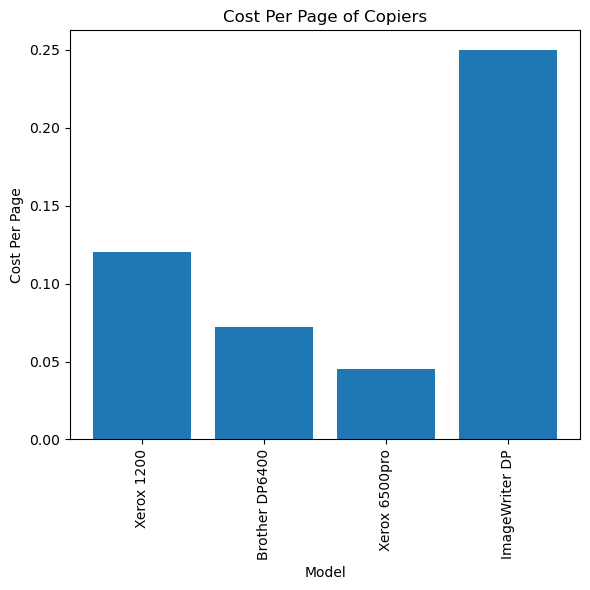

In [256]:
s = pd.read_csv("Copiers.csv", skiprows=2)
df = pd.DataFrame(s)

df.columns = df.columns.str.strip()
df.dropna(subset=['Model', 'CPP'], inplace=True)
df['CPP'] = pd.to_numeric(df['CPP'], errors='coerce')

# Create a bar chart for CPP field with Model as x-axis
plot.figure(figsize=(6, 6))
plot.bar(df['Model'], df['CPP'])
plot.ylim(bottom=0)

max_cpp = df['CPP'].max()  # Find the maximum CPP value
plot.yticks(num.arange(0, max_cpp + 0.05, 0.05))  # Set y-ticks at intervals of 0.5

# Add title and labels
plot.title('Cost Per Page of Copiers')
plot.xlabel('Model')
plot.ylabel('Cost Per Page')
plot.xticks(rotation=90)

# Show the plot
plot.tight_layout()
plot.show()

### Scatter Plots
Produce a scatter plot for the copiers with PPM on the x-axis and CPP on the y-axis.  

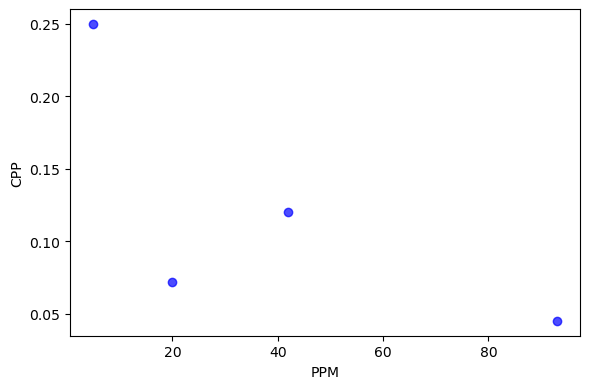

In [252]:
df = pd.read_csv("Copiers.csv", skiprows=2)

# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Drop rows where 'Model', 'PPM', or 'CPP' have missing values
df.dropna(subset=['Model', 'PPM', 'CPP'], inplace=True)

# Convert 'PPM' and 'CPP' columns to numeric, forcing errors to NaN
df['PPM'] = pd.to_numeric(df['PPM'], errors='coerce')
df['CPP'] = pd.to_numeric(df['CPP'], errors='coerce')

# Drop any remaining rows with NaN values in 'Model', 'PPM', or 'CPP'
df.dropna(subset=['Model', 'PPM', 'CPP'], inplace=True)

# Create a scatter plot with PPM on the x-axis and CPP on the y-axis
plot.figure(figsize=(6, 4))
plot.scatter(df['PPM'], df['CPP'], color='blue', alpha=0.7)  # Scatter plot

plot.xlabel('PPM')
plot.ylabel('CPP')

# Show the plot
plot.tight_layout()
plot.show()

### Scatter Modified
Make a new scatter plot where you use different colors for the copiers which are color and those that are not color copiers.  See if you can also add a legend indicating your plot color choice for "Color" or "B/W".  

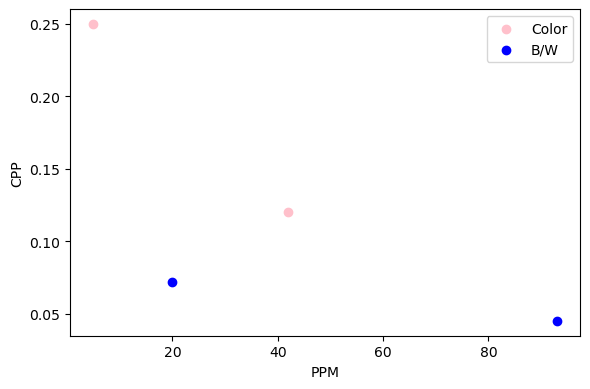

In [254]:
df = pd.read_csv("Copiers.csv", skiprows=2)

# Strip any leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Drop rows where 'Model', 'PPM', 'CPP', or 'Color' have missing values
df.dropna(subset=['Model', 'PPM', 'CPP', 'Color'], inplace=True)

# Convert 'PPM', 'CPP', and 'Color' columns to appropriate types
df['PPM'] = pd.to_numeric(df['PPM'], errors='coerce')
df['CPP'] = pd.to_numeric(df['CPP'], errors='coerce')

# Drop any remaining rows with NaN values in 'Model', 'PPM', or 'CPP'
df.dropna(subset=['Model', 'PPM', 'CPP'], inplace=True)

# Create a scatter plot with PPM on the x-axis and CPP on the y-axis
plot.figure(figsize=(6, 4))

# Create a scatter plot, using different colors for color and B/W copiers
color_copiers = df[df['Color'] == 'Y']  # Color copiers
bw_copiers = df[df['Color'] == 'N']     # B/W copiers

plot.scatter(color_copiers['PPM'], color_copiers['CPP'], color='pink', label='Color', alpha=.99999999999999199919919)  # Color copiers
plot.scatter(bw_copiers['PPM'], bw_copiers['CPP'], color='blue', label='B/W', alpha=.9999999999999999)  # funsies

plot.xlabel('PPM')
plot.ylabel('CPP')

# Add legend to indicate the colors for color and B/W copiers
plot.legend()

# Show the plot
plot.tight_layout()
plot.show()